In [1]:
import os

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from ipywidgets import interact
from sklearn import datasets, neighbors, preprocessing, tree
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree


In [2]:
# load the dataset with pandas
df = pd.read_csv('fertilizer_recommendation_dataset.csv')
# rename the target col
# 将 Fertilizer 重命名为 target
df = df.rename(columns={'Fertilizer': 'target'})
print(df.head())  # display top 5 of the data
print("----------------------------------")
print("----------------------------------")
print(df.info())
print("----------------------------------")
print("----------------------------------")
print(df.describe())

   Temperature  Moisture    Rainfall        PH   Nitrogen  Phosphorous  \
0    50.179845  0.725893  205.600816  6.227358  66.701872    76.963560   
1    21.633318  0.721958  306.081601  7.173131  71.583316   163.057636   
2    23.060964  0.685751  259.336414  7.380793  75.709830    62.091508   
3    26.241975  0.755095  212.703513  6.883367  78.033687   151.012521   
4    21.490157  0.730672  268.786767  7.578760  71.765123    66.257371   

    Potassium    Carbon        Soil  Crop                      target  \
0   96.429065  0.496300  Loamy Soil  rice                     Compost   
1  148.128347  1.234242  Loamy Soil  rice     Balanced NPK Fertilizer   
2   80.308971  1.795650  Peaty Soil  rice  Water Retaining Fertilizer   
3  153.005712  1.517556  Loamy Soil  rice     Balanced NPK Fertilizer   
4   97.000886  1.782985  Peaty Soil  rice          Organic Fertilizer   

                                              Remark  
0  Enhances organic matter and improves soil stru...  
1  Pro

target
DAP                           1054
Water Retaining Fertilizer     675
Compost                        375
Muriate of Potash              326
Lime                           181
Balanced NPK Fertilizer        157
Urea                           154
Organic Fertilizer              95
Gypsum                          52
General Purpose Fertilizer      31
Name: count, dtype: int64

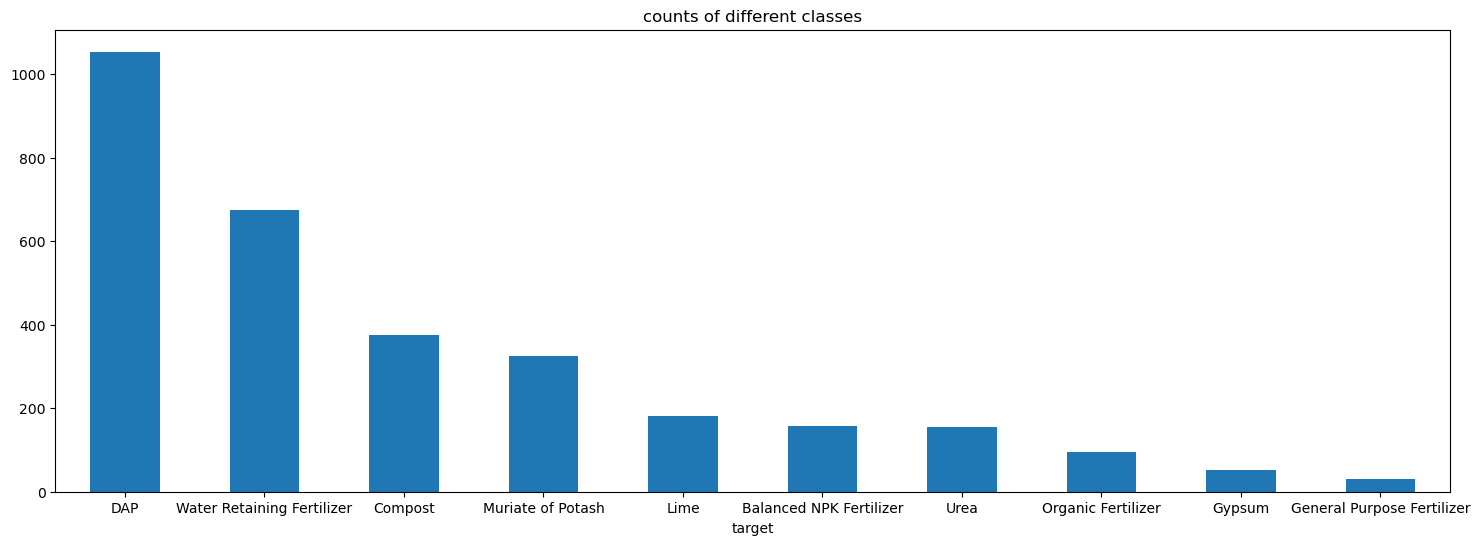

In [3]:
plt.figure(num=1, clear=True, figsize=(18, 6))
display(df.target.value_counts())
df.target.value_counts().plot(kind="bar", title="counts of different classes", rot=0)
plt.show()

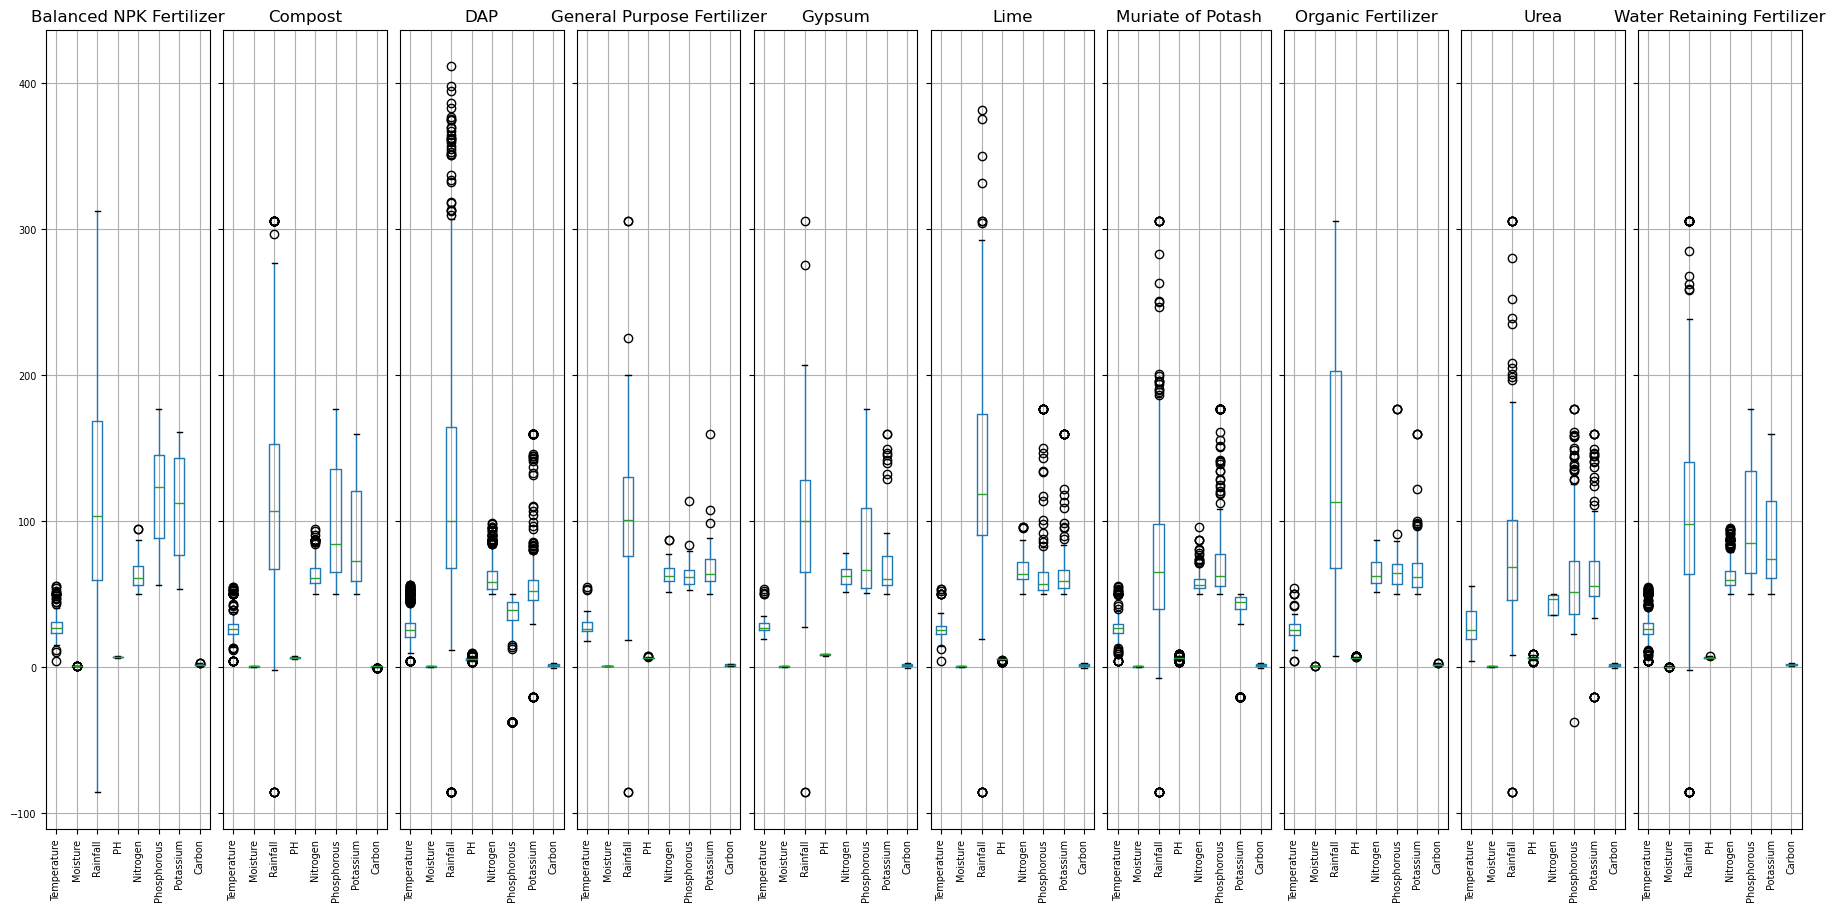

In [4]:
def show_feature_statistics(df, **kwargs): 
    grps = df.groupby("target", observed=False)
    fig, axes = plt.subplots(nrows=1, ncols=len(grps), sharey=True, clear=True, figsize=(18, 9), layout="constrained", squeeze=False, **kwargs)
    for grp, ax in zip(df.groupby("target", observed=False), axes[0]):
        grp[1].boxplot(rot=90, fontsize=7, ax=ax).set_title(grp[0])
    plt.show()

show_feature_statistics(df, num=2)

negative counts:
Temperature     0
Moisture        0
Rainfall       75
PH              0
Nitrogen        0
Phosphorous    78
Potassium      71
Carbon         85
dtype: int64


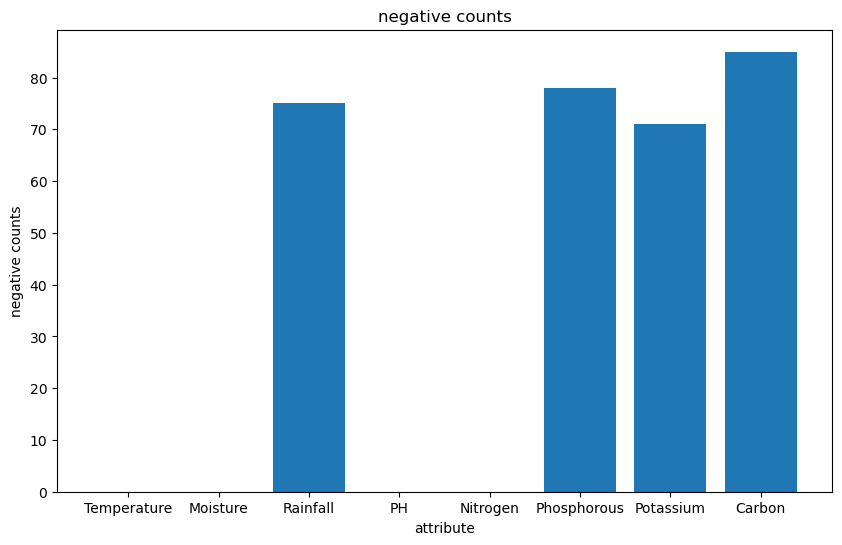

In [5]:
def count_negative_per_column(data):
    # 筛选出数值类型的列
    numeric_columns = data.select_dtypes(include=['number']).columns
    # 统计每列中负数的数量
    negative_counts = (data[numeric_columns] < 0).sum()
    return negative_counts

# 调用函数统计每列的负数数量
negative_counts = count_negative_per_column(df)
print("negative counts:")
print(negative_counts)

# 绘制柱状图
plt.figure(figsize=(10, 6))
plt.bar(negative_counts.index, negative_counts.values)
plt.xlabel('attribute')
plt.ylabel('negative counts')
plt.title('negative counts')
plt.show()

# show negative_scatter plot

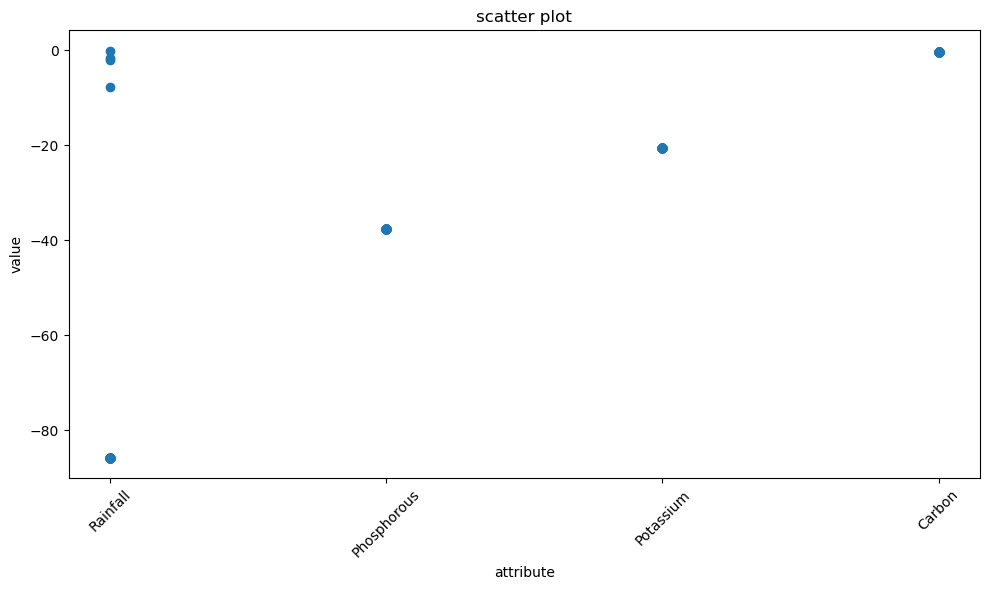

In [6]:
def plot_negative_scatter(data):
    # 筛选出数值类型的列
    numeric_columns = data.select_dtypes(include=['number']).columns
    # 提取负数数据
    negative_data = data[numeric_columns][data[numeric_columns] < 0]
    # 把数据从宽格式转换为长格式
    melted_data = negative_data.reset_index().melt(
        id_vars='index', var_name='column', value_name='value')
    # 去除缺失值
    melted_data = melted_data.dropna()

    # 绘制散点图
    plt.figure(figsize=(10, 6))
    plt.scatter(melted_data['column'], melted_data['value'])
    plt.xlabel('attribute')
    plt.ylabel('value')
    plt.title('scatter plot')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 调用函数进行可视化
plot_negative_scatter(df)

# show negative table

In [7]:
def show_negative_values_table(data):
    # 筛选出数值类型的列
    numeric_columns = data.select_dtypes(include=['number']).columns
    negative_data = data[numeric_columns][data[numeric_columns] < 0]
    result = {}
    for col in negative_data.columns:
        non_na_values = negative_data[col].dropna()
        result[col] = [non_na_values.tolist()]
    table = pd.DataFrame(result)
    return table

# 调用函数生成表格
table = show_negative_values_table(df)
print(table)

  Temperature Moisture                                           Rainfall  PH  \
0          []       []  [-85.70959335, -85.70959335, -85.70959335, -85...  []   

  Nitrogen                                        Phosphorous  \
0       []  [-37.64973873, -37.64973873, -37.64973873, -37...   

                                           Potassium  \
0  [-20.50910839, -20.50910839, -20.50910839, -20...   

                                              Carbon  
0  [-0.280559958, -0.280559958, -0.280559958, -0....  
